# Unlock Your Full Potential as a Business Analyst With the Powerful Causal Impact Framework

Credit to Juan Jose Muñoz Panos in https://www.kaggle.com/code/juanjosemuozpanos/causal-impact-framework

**Causal inference can help you become a business analyst rockstar.**

In a business context, the leadership is often interested in the impact of a decision or event on the KPI of interest. As a performance analyst, I spend most of my time answering some variant of this question: “What is the impact of {News, government announcement, special event…} in the Country’s X performance?”. Intuitively, we can answer this question if we had a way of knowing what would have happened if the News/ announcement/ Special event had never happened.

**This is the essence of causal inference, and some very talented people are working hard to make causal inference frameworks available for us to use.**

Google Causal Impact library is one of those frameworks. Developed by Google to help them make better marketing budget decisions, this library can help us quantify the impact of any event or intervention on a time series of interest. It may sound scary, but it's actually quite intuitive.
As business analysts, we should leverage these tools in our day-to-day lives; here are 5 easy steps you can take to implement your first Causal Impact analysis.


In [1]:
from causalimpact import CausalImpact
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# If data/example.csv is missing, generate it first:
#   python generate_example_data.py
DATA_PATH = Path('data') / 'example.csv'


# Import Data and define pre/post periods

**We can think of the Causal Impact framework as a time series problem.**
On a specific date, we observe an event, news, etc.… and track how our measure of interest changes after this event compared to some baseline. You can think of your baseline as a control group. 

To perform a Causal Impact analysis, we will need the following:

* Date of the event to study
* Time Series of our variable of interest for our impacted unit
* Time Series of our variable of interest for other multiple units that were not impacted by the event

For my example, I am using a made-up scenario as follows:

* Event: Global conference happened on September 6th in Barcelona
* Variable of Interest: Passenger revenue for an airline
* Impacted Unit: Barcelona
* Control group: Other European Markets
* Question: What was the impact of the Conference on Passenger revenue in Barcelona?

When considering the time frame, you should aim to keep the post-period as short as possible, and the pre-period should be longer than your post-period.


In [2]:
# set time periods
training_strat = "2022-03-10"
training_end = "2022-06-30"
treatment_start = "2022-07-01"
treatment_end = "2022-07-13"

In [3]:
data = pd.read_csv(DATA_PATH, index_col='Date', parse_dates=True)
data.index.freq = 'd'
data.index


DatetimeIndex(['2022-03-10', '2022-03-11', '2022-03-12', '2022-03-13',
               '2022-03-14', '2022-03-15', '2022-03-16', '2022-03-17',
               '2022-03-18', '2022-03-19',
               ...
               '2022-07-05', '2022-07-06', '2022-07-07', '2022-07-08',
               '2022-07-09', '2022-07-10', '2022-07-11', '2022-07-12',
               '2022-07-13', '2022-07-14'],
              dtype='datetime64[ns]', name='Date', length=127, freq='D')

In [4]:
data.head()

,Barcelona,London,Paris,Berlin,Rome,Madrid,Moscow,Istanbul,Kiev,Vienna,...,Lisbon,Edinburgh,Porto,Glasgow,Reykjavik,Belgrade,Krakow,Seville,Turin,The Hague
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-10,173678.599727,118972.381896,451717.252872,421804.191310,81629.909018,39031.852773,131567.181464,152606.512812,277647.784127,344603.380426,...,489039.711237,126498.625905,376929.892995,207481.393510,587270.517928,128705.402708,64388.688402,196882.117288,47002.243833,NaN
2022-03-11,174204.158857,115902.749352,433100.069945,435520.219408,68976.556430,36666.998860,114813.571840,120911.689429,261079.855319,384210.913651,...,458614.282516,113091.121161,361832.112850,199866.919227,648779.651004,135913.703955,66353.703383,262770.605961,32941.127196,NaN
2022-03-12,166480.965666,108636.432694,468749.352935,429105.427539,82724.758586,46345.568886,113004.549952,141197.525506,245632.649200,289818.375620,...,524398.518012,122396.247048,358393.796085,174726.383608,613855.099379,127470.180175,70962.392745,182336.359682,54524.223750,NaN
2022-03-13,172205.411166,110807.873071,522324.489010,459417.052066,91207.622432,46499.746926,126027.845065,120070.980885,273685.048064,294209.759191,...,521010.697012,112808.466297,391922.504303,191991.160067,556379.427778,125437.116436,65208.561809,251873.420394,48160.626729,NaN
2022-03-14,169090.361776,99687.165212,517045.180345,443994.817970,79420.352664,45291.338922,106466.419094,145857.330551,257153.227142,373050.139426,...,487315.216317,118320.679162,411588.150691,195858.334002,593659.349107,123900.280139,67646.165623,234130.052307,43120.521426,NaN


# Creating a Control Group

**This step is the most critical part.**

To estimate the impact of any event or treatment, we need to know our unit of interest (example Barcelona Passenger Revenue) under the treatment and under no treatment. This is the main problem of causal inference.

>we can never observe our unit of interest under two mutually exclusive circumstances. The solution is to create a counterfactual scenario.

You can think of a counterfactual as a hypothetical scenario where the event/treatment did not occur.

Our control group will help us create this scenario. To decide which markets to include in our control group, we need to calculate which markets have predictive power to predict our market of interest (Barcelona). We will use correlation to establish this predictive power.
This step needs to be done in order the PRE-TREATMENT  period only.


In [5]:
# get the training data only
df_training = data[data.index <= pd.to_datetime(training_end)]
df_training.tail()

,Barcelona,London,Paris,Berlin,Rome,Madrid,Moscow,Istanbul,Kiev,Vienna,...,Lisbon,Edinburgh,Porto,Glasgow,Reykjavik,Belgrade,Krakow,Seville,Turin,The Hague
Date,,,,,,,,,,,,,,,,,,,,,
2022-06-26,153933.020640,102521.925567,491560.297851,482243.845932,81578.454827,34448.871373,127533.268754,142376.907488,235106.256468,320234.214758,...,444603.518881,107809.460705,347941.841289,192823.364345,598073.918982,121740.799118,75743.368688,200896.480732,42496.685949,NaN
2022-06-27,148375.918038,110886.850859,457753.077080,416849.803059,76012.906598,40809.205335,121406.919781,137457.861677,261643.499565,360159.391527,...,487493.075492,131173.040193,352317.101649,202956.959105,639854.510077,134079.420236,66637.659187,255557.121069,47690.696131,NaN
2022-06-28,161440.122637,125281.673328,489319.223692,433191.479210,72744.992501,40127.352532,124681.370799,161513.970489,244080.508963,325024.902828,...,523159.941005,94921.687726,427615.805636,192248.606899,505639.489644,128350.556774,66688.893563,248643.873219,44707.958949,NaN
2022-06-29,156674.500392,105344.034747,459840.320950,441377.033154,78414.376928,40511.491757,127884.476687,143518.717904,258989.668403,331868.487813,...,524497.982246,117214.348983,410523.424021,210855.136423,595549.483878,128501.152938,78731.755007,255515.576268,50497.275830,NaN
2022-06-30,158290.681807,104639.181061,507018.046627,410661.927059,76466.992837,40758.018787,117738.058044,160428.849447,232064.370577,392172.978272,...,513862.922529,115523.924701,374817.034233,172142.280184,577757.251360,139187.983113,74894.875288,245229.384908,43526.850324,NaN


In [6]:
# Check  for stationarity
from statsmodels.tsa.stattools import adfuller

test = adfuller(x = df_training['Barcelona'])[1]
print(test)
if test< 0.05:
    print("Data is stationary")
else:
    print("Time series is not stationary")

0.9757381279853794
Time series is not stationary


In [7]:
# making data stationary by differencing

differencing = df_training.pct_change().dropna(thresh = 1,axis=1).dropna()
differencing.head()

/var/folders/w4/5w00hfd148b_j0jvq_ns2kq80000gn/T/ipykernel_24768/4119699551.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  differencing = df_training.pct_change().dropna(thresh = 1,axis=1).dropna()


,Barcelona,London,Paris,Berlin,Rome,Madrid,Moscow,Istanbul,Kiev,Vienna,...,Nice,Lisbon,Edinburgh,Porto,Glasgow,Reykjavik,Belgrade,Krakow,Seville,Turin
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-11,0.003026,-0.025801,-0.041214,0.032518,-0.155009,-0.060588,-0.127339,-0.207690,-0.059672,0.114937,...,-0.176649,-0.062215,-0.105989,-0.040055,-0.036700,0.104737,0.056006,0.030518,0.334660,-0.299158
2022-03-12,-0.044334,-0.062693,0.082312,-0.014729,0.199317,0.263959,-0.015756,0.167774,-0.059167,-0.245679,...,0.062331,0.143441,0.082280,-0.009503,-0.125786,-0.053831,-0.062124,0.069456,-0.306101,0.655202
2022-03-13,0.034385,0.019988,0.114294,0.070639,0.102543,0.003327,0.115246,-0.149624,0.114205,0.015152,...,0.043894,-0.006460,-0.078334,0.093553,0.098810,-0.093631,-0.015949,-0.081083,0.381367,-0.116711
2022-03-14,-0.018089,-0.100360,-0.010107,-0.033569,-0.129236,-0.025987,-0.155215,0.214759,-0.060405,0.267973,...,0.150298,-0.064673,0.048863,0.050177,0.020142,0.067004,-0.012252,0.037382,-0.070446,-0.104652
2022-03-15,0.050887,0.102176,-0.030382,0.025200,-0.040190,-0.079659,0.175599,-0.003246,-0.020296,-0.055308,...,-0.166564,-0.017902,0.204322,-0.104639,-0.034433,0.122825,0.090521,-0.059390,-0.187435,0.201684


In [8]:
test = adfuller(x = differencing['Barcelona'])[1]
print(test)
if test< 0.05:
    print("Data is stationary")
else:
    print("Time series is not stationary")

1.799121554513031e-15
Data is stationary


In [9]:
# Check Top correlatted markets
market_cor= pd.Series(differencing.corr().abs()['Barcelona'])
market_cor[market_cor >=0.3]

Barcelona    1.0
Name: Barcelona, dtype: float64

In [10]:
#Markets to keep for model
markets_to_keep = list(market_cor[market_cor >=0.3].index)

markets_to_keep

['Barcelona']

# Implementing CausalImpact

Now, we are ready to implement CausalImpact.

In a nutshell, CausalImpact will use our control group to learn to predict the Passenger Revenue in Barcelona during the Pre-period. The model will use this to predict the counterfactual post-period scenario where the Conference did not happen.

The Delta between what actually happened and the counterfactual scenario is the impact of the conference.


In [11]:
#Keep only markets on the above list

final_data = data.drop(columns=[col for col in data if col not in markets_to_keep])

In [12]:
#Prepare Pre and Post periods
pre_period = [training_strat,training_end]
post_period = [treatment_start,treatment_end]

In [13]:
impact = CausalImpact(data=final_data,
                      pre_period=pre_period,
                      post_period=post_period)

/Users/willd/Development/applied-ds-engineering/.venv/lib/python3.14/site-packages/causalimpact/main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
/Users/willd/Development/applied-ds-engineering/.venv/lib/python3.14/site-packages/causalimpact/main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
/Users/willd/Development/applied-ds-engineering/.venv/lib/python3.14/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments 

# Interpreting results & Validation

Google CausalImpact makes it very easy to visualize and summarize the results.


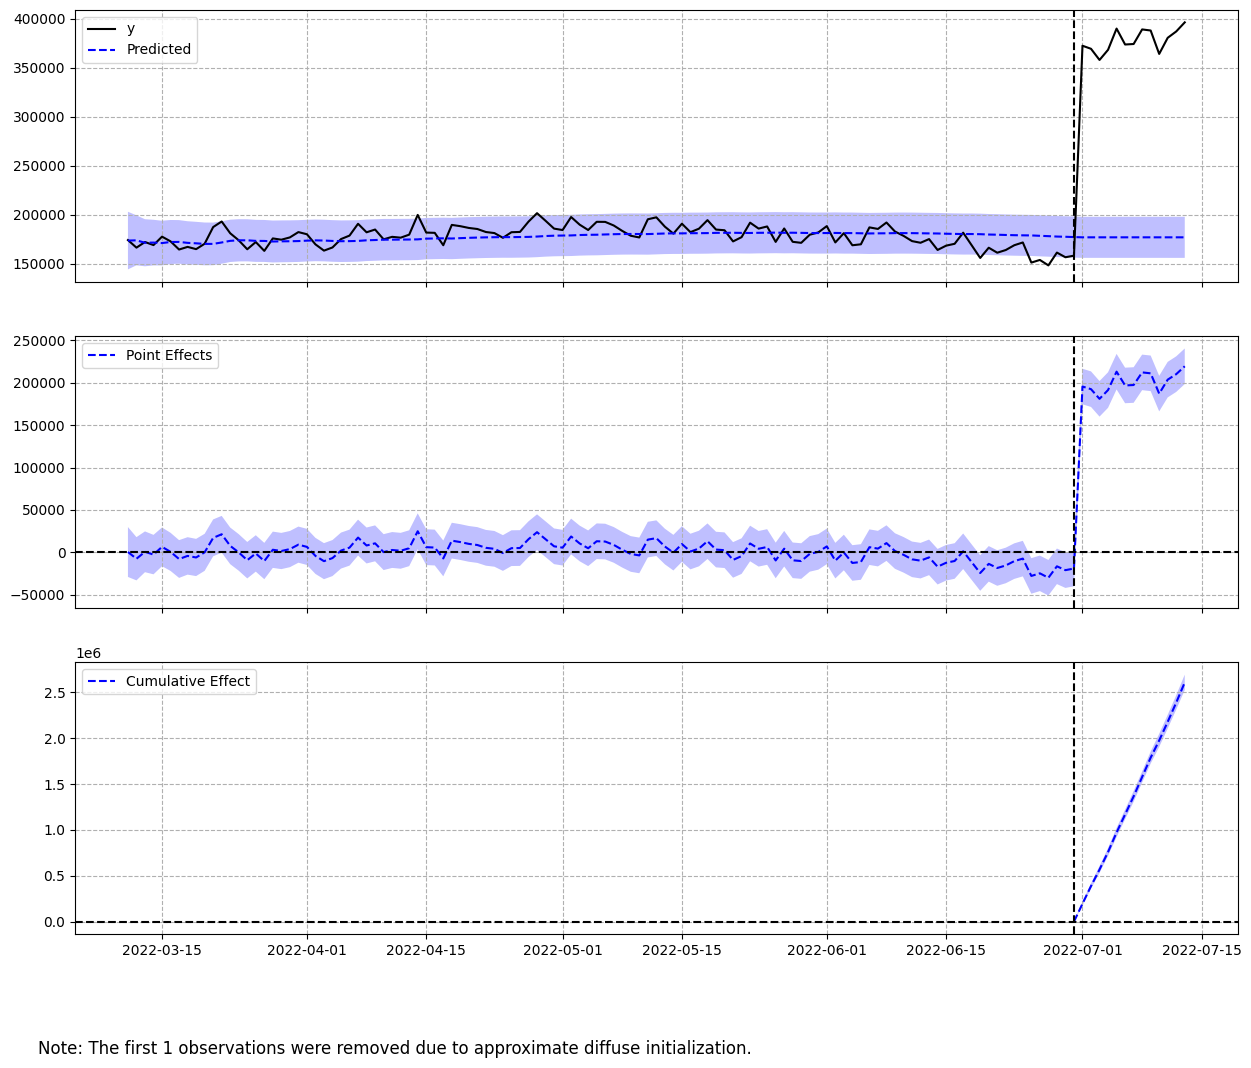

In [14]:
impact.plot()

In [15]:
print(impact.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    377673.99          4909761.82
Prediction (s.d.)         176999.56 (3311.13)2300994.31 (43044.74)
95% CI                    [170399.64, 183379.05][2215195.33, 2383927.61]

Absolute effect (s.d.)    200674.42 (3311.13)2608767.51 (43044.74)
95% CI                    [194294.94, 207274.35][2525834.22, 2694566.49]

Relative effect (s.d.)    113.38% (1.87%)    113.38% (1.87%)
95% CI                    [109.77%, 117.1%]  [109.77%, 117.1%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [16]:
print(impact.summary('report'))

Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 377673.99. By contrast, in the absence of an
intervention, we would have expected an average response of 176999.56.
The 95% interval of this counterfactual prediction is [170399.64, 183379.05].
Subtracting this prediction from the observed response yields
an estimate of the causal effect the intervention had on the
response variable. This effect is 200674.42 with a 95% interval of
[194294.94, 207274.35]. For a discussion of the significance of this effect,
see below.


Summing up the individual data points during the post-intervention
period (which can only sometimes be meaningfully interpreted), the
response variable had an overall value of 4909761.82.
By contrast, had the intervention not taken place, we would have expected
a sum of 2300994.31. The 95% interval of this prediction is [2215195.33, 2383927.61].


The above results are given in terms of absolute num

Depending on what you are measuring, you might be interested in average impact or cumulative impact. In our case, we are interested in the cumulative impact over the period of the conference.

Based on the analysis, the conference contributed to +3M upside in Passenger revenue.

Unlike in machine learning, there are no accuracy measures for Causal Impact, which can make validation a bit tricky. However there are 3 things you can do to validate your results.

1. Ensure your confidence interval in Pre period is not too broad – this could indicate that your control group is not predictive enough
2. Ensure the confidence interval of the estimated impact does not contain 0
3. Use refutation tests, for example, if you conduct the same analysis but change the event date to any day in the pre-period, the impact should be 0
